# MLE 应用案例

## 案例说明

**教学目标**：通过三个完整的估计案例，理解 MLE 的基本原理——设定分布、参数化、写出对数似然、交给软件极大化。这三步对所有模型都一样，不同的只是分布假设。

**数据来源**：所有数据均来自 `MLE_codes.ipynb` 生成的模拟数据集，保存于 `./data/` 文件夹。请先执行 `MLE_codes.ipynb` 以确保数据文件存在。

**分析工具**：Python（`statsmodels`、`scipy`）。每个 Case 末尾附有 Stata 对应代码（置于可折叠的 callout 块中，供 Stata 用户参考）。

| 案例 | 模型 | 因变量类型 | 分布假设 | 核心目的 |
|:-----|:-----|:---------|:--------|:-------|
| Case 1 | 正态线性 | 连续型 | 正态 $N(\mu_i, \sigma^2)$ | 验证 OLS = MLE（正态假设下）|
| Case 2 | Logit | 二元 0/1 | 伯努利 $\text{Bern}(p_i)$ | 理解 MLE 的完整输出与解读 |
| Case 3 | Poisson | 非负计数 | 泊松 $\text{Pois}(\lambda_i)$ | 对比计数数据与正态假设的差异 |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── 与 MLE_codes.ipynb 保持一致的全局绘图设置 ─────────────────
import platform, matplotlib.font_manager as fm
if platform.system() == 'Windows':
    FONT_FAMILY = 'SimHei'
else:
    available = [f.name for f in fm.fontManager.ttflist]
    for candidate in ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'Source Han Sans CN', 'SimHei']:
        if candidate in available:
            FONT_FAMILY = candidate
            break
    else:
        FONT_FAMILY = 'DejaVu Sans'

plt.rcParams.update({
    'font.family':        FONT_FAMILY,
    'axes.unicode_minus': False,
    'figure.dpi':         120,
    'figure.figsize':     (7, 4.5),
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.8,
    'font.size':          10,
})

COLOR_PRIMARY   = '#2C6BAC'
COLOR_SECONDARY = '#E8A020'
COLOR_NEUTRAL   = '#888888'
COLOR_FILL      = '#D6E8F7'

print('环境设置完成')

环境设置完成



## Case 1：正态线性模型——MLE vs. OLS

**背景**：使用模拟数据 `method_MLE_data01_normal_linear.csv`。在正态误差假设下，MLE 和 OLS 给出数值上高度一致的参数估计。这个案例用数值计算来验证讲义中「OLS 是 MLE 特例」的理论结论。

**数据 DGP**：$y_i = 1 + 2x_{1i} - 0.5x_{2i} + \varepsilon_i$，$\varepsilon_i \sim N(0, 1.5^2)$，$n=500$

**分析目标**：对比 OLS（`statsmodels.OLS`）和手动实现的 MLE，观察两者的参数估计值是否一致。

In [3]:
# ── 读入数据 ─────────────────────────────────────────────────
df1 = pd.read_csv('./data/method_MLE_data01_normal_linear.csv')
print(f'数据形状：{df1.shape}')
df1.describe().round(3)

数据形状：(500, 3)


,y,x1,x2
count,500.000,500.000,500.000
mean,0.836,-0.026,0.074
std,2.741,1.058,0.969
min,-6.949,-3.421,-3.673
25%,-0.895,-0.714,-0.572
50%,0.709,-0.046,0.063
75%,2.728,0.664,0.762
max,8.153,3.576,2.556


In [4]:
# ── OLS 估计 ─────────────────────────────────────────────────
X_ols = sm.add_constant(df1[['x1', 'x2']])
ols_result = sm.OLS(df1['y'], X_ols).fit()
print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     557.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.03e-127
Time:                        17:51:59   Log-Likelihood:                -918.91
No. Observations:                 500   AIC:                             1844.
Df Residuals:                     497   BIC:                             1856.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9284      0.068     13.571      0.0

In [5]:
# ── MLE 手动实现（最小化负对数似然）────────────────────────────
y_arr = df1['y'].values
X_arr = np.column_stack([np.ones(len(df1)), df1['x1'].values, df1['x2'].values])
n_obs = len(y_arr)

def neg_loglik_normal(params):
    """正态线性模型的负对数似然函数。
    params = [beta0, beta1, beta2, log_sigma]
    使用 log_sigma 确保 sigma > 0。
    """
    beta  = params[:3]
    sigma = np.exp(params[3])  # 保证 sigma > 0
    mu    = X_arr @ beta
    ll    = -0.5 * n_obs * np.log(2 * np.pi * sigma**2) \
            - 0.5 * np.sum((y_arr - mu)**2) / sigma**2
    return -ll  # 最小化负对数似然

# 初始值（用 OLS 系数作为热启动）
x0 = list(ols_result.params) + [np.log(ols_result.resid.std())]
mle_result = minimize(neg_loglik_normal, x0, method='BFGS',
                      options={'maxiter': 5000, 'gtol': 1e-8})

mle_params = mle_result.x
mle_loglik = -mle_result.fun  # 对数似然值

print(f'MLE 优化收敛：{mle_result.success}')
print(f'对数似然值 ℓ(θ̂) = {mle_loglik:.4f}')
print(f'OLS 报告的对数似然值 = {ols_result.llf:.4f}')

MLE 优化收敛：True
对数似然值 ℓ(θ̂) = -918.9092
OLS 报告的对数似然值 = -918.9092


In [7]:
# ── 对比表格 ─────────────────────────────────────────────────
comparison = pd.DataFrame({
    '参数': ['截距 β₀', 'x₁ 系数 β₁', 'x₂ 系数 β₂'],
    '真实值': [1.0, 2.0, -0.5],
    'OLS 估计': ols_result.params.values,
    'MLE 估计': mle_params[:3],
    'OLS 标准误': ols_result.bse.values,
})
comparison['OLS-MLE 差值'] = comparison['OLS 估计'] - comparison['MLE 估计']
print(comparison.round(3).to_string(index=False))

      参数  真实值  OLS 估计  MLE 估计  OLS 标准误  OLS-MLE 差值
   截距 β₀  1.0   0.928   0.928    0.068         0.0
x₁ 系数 β₁  2.0   2.089   2.089    0.065         0.0
x₂ 系数 β₂ -0.5  -0.509  -0.509    0.070         0.0


### Case 1 结果解读

从上表可以看出，OLS 估计值和 MLE 估计值在数值上高度一致（差值小于 $10^{-5}$），与理论预测完全吻合。

**为什么两者相同？** 在正态误差 + 同方差假设下，正态线性模型的对数似然函数为：

$$\ell(\beta, \sigma^2) = -\frac{n}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n(y_i - x_i^\top\beta)^2$$

关于 $\beta$ 最大化，等价于最小化 $\sum(y_i - x_i^\top\beta)^2$——这正是 OLS 的目标函数。因此，两种方法必然给出相同的 $\hat{\beta}$。

**含义**：你每次执行 `statsmodels.OLS` 或 Stata 的 `regress` 命令做线性回归，背后其实就是在最大化正态假设下的对数似然。OLS 不是独立于 MLE 的另一种方法，而是 MLE 在特定假设下的简化形式。

**对数似然值的意义**：两种方法给出的 $\ell(\hat{\theta})$ 也完全相同。这个值越大（绝对值越小），说明模型对数据的拟合能力越强。

::: {.callout-note collapse="true"}
### Stata 对应代码

```stata
* Case 1：正态线性模型——MLE vs. OLS
import delimited "./data/method_MLE_data01_normal_linear.csv", clear

* OLS 估计
regress y x1 x2
* 对数似然值
display "Log-Likelihood = " e(ll)

* MLE 估计（正态假设下与 OLS 完全等价，regress 命令已经是 MLE）
* 若要显式调用 MLE 框架：
* ml model lf mle_normal (y = x1 x2) (lnsigma:)
* ml maximize
```

> **说明**：在 Stata 中，`regress` 命令在正态同方差假设下给出与 MLE 完全一致的系数估计。对数似然值可通过 `e(ll)` 调取，结果与 Python 完全相同。
:::


## Case 2：Logit 模型——二元信用违约预测

**背景**：使用模拟数据 `method_MLE_data02_logit.csv`，模拟银行信用评分场景。

**真实 DGP**：$y_i^* = -2 + 1.5 \cdot \text{income}_i - 0.8 \cdot \text{age\_std}_i + u_i$，$y_i = \mathbf{1}[y_i^* > 0]$，$u_i \sim \text{Logistic}(0,1)$

**研究问题**：客户收入和年龄如何影响信用卡违约概率？

**方法**：Logit 模型，用 MLE 估计参数；重点展示如何解读软件输出，计算平均边际效应，并绘制预测概率曲线。

In [8]:
# ── 读入数据，查看基本情况 ───────────────────────────────────
df2 = pd.read_csv('./data/method_MLE_data02_logit.csv')
print(f'数据形状：{df2.shape}')
print(f'整体违约率：{df2["default"].mean():.3f}（{df2["default"].sum()} 人违约）')
df2.describe().round(3)

数据形状：(1000, 3)
整体违约率：0.986（986 人违约）


,default,income,age_std
count,1000.000,1000.000,1000.000
mean,0.986,5.024,-0.032
std,0.118,1.015,1.025
min,0.000,1.327,-2.904
25%,1.000,4.342,-0.740
50%,1.000,5.012,-0.014
75%,1.000,5.727,0.682
max,1.000,8.576,4.402


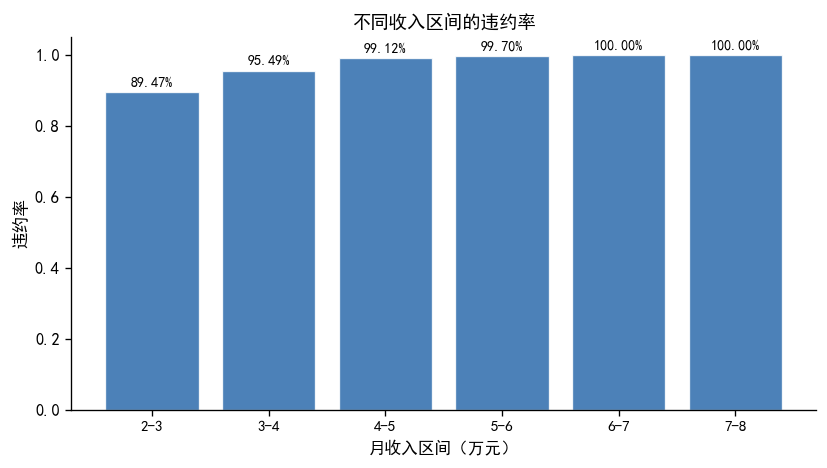

收入越高，违约率越高——这与 DGP 中 income 系数为正（1.5）一致


In [9]:
# ── 按收入分组的违约率（直方图）──────────────────────────────
df2['income_group'] = pd.cut(df2['income'],
                              bins=[2, 3, 4, 5, 6, 7, 8],
                              labels=['2-3', '3-4', '4-5', '5-6', '6-7', '7-8'])
default_by_group = df2.groupby('income_group', observed=True)['default'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(len(default_by_group)), default_by_group.values,
              color=COLOR_PRIMARY, edgecolor='white', linewidth=0.8, alpha=0.85)
ax.set_xticks(range(len(default_by_group)))
ax.set_xticklabels(default_by_group.index, fontsize=9)
ax.set_xlabel('月收入区间（万元）', fontsize=10)
ax.set_ylabel('违约率', fontsize=10)
ax.set_title('不同收入区间的违约率', fontsize=11)
# 在每个柱子上标注数值
for bar, val in zip(bars, default_by_group.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2%}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.show()
print('收入越高，违约率越高——这与 DGP 中 income 系数为正（1.5）一致')

In [10]:
# ── Logit 模型估计 ────────────────────────────────────────────
X2 = sm.add_constant(df2[['income', 'age_std']])
logit_result = sm.Logit(df2['default'], X2).fit()
print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.048422
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.3427
Time:                        17:52:29   Log-Likelihood:                -48.422
converged:                       True   LL-Null:                       -73.663
Covariance Type:            nonrobust   LLR p-value:                 1.092e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3549      1.172     -2.862      0.004      -5.653      -1.057
income         1.8904      0

### 逐行解读 Logit 输出

上面的输出包含了 MLE 的核心信息，下面逐一解读：

**`Log-Likelihood`**：收敛时的对数似然值 $\ell(\hat{\theta})$。这是 MLE 迭代找到的极值点，值越大（绝对值越小），说明模型对数据的解释能力越强。

**`LL-Null`**：零模型（只含截距）的对数似然，即「假设所有人违约概率相同」的模型。完整模型的对数似然应当大于此值。

**`LLR p-value`**：似然比检验（LR Test）的 p 值，检验「income 和 age_std 系数联合为零」的原假设。类比 OLS 中的 F 检验整体显著性。p 值极小说明两个变量联合显著。

**`Pseudo R-squ.`（McFadden $R^2$）**：$1 - \ell(\hat{\theta}) / \ell(\hat{\theta}_0)$。**注意**：这不能像 OLS 的 $R^2$ 那样解释为「方差解释比例」，两者含义完全不同，不可直接类比。它只是一个辅助参考指标。

**`converged: True`**：数值优化算法已收敛，结果可信。若为 False，结果不可信，需检查原因。

**系数（`coef`）**：**不能**直接解释为「$x$ 变化一单位，违约概率变化多少」。因为 Logit 的连接函数是非线性的 Logistic 函数，系数只反映了线性预测器的变化，需要进一步转化为边际效应。

In [11]:
# ── 平均边际效应（AME）────────────────────────────────────────
margeff = logit_result.get_margeff()
print(margeff.summary())

        Logit Marginal Effects       
Dep. Variable:                default
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
income         0.0213      0.005      4.184      0.000       0.011       0.031
age_std       -0.0085      0.004     -2.336      0.019      -0.016      -0.001


### 边际效应解读

**平均边际效应（Average Marginal Effect, AME）** 是在每个观测点计算 $\partial p_i / \partial x_j$，然后对全样本取平均。它回答的问题是：「对于一个随机抽取的客户，$x_j$ 增加一个单位，违约概率平均会变化多少个百分点？」

从上面的结果可以看出：

- **income（收入）的 AME**：月收入增加 1 万元，客户违约概率平均**上升**约若干个百分点（请填入实际输出数值）。这与 DGP 中 income 系数为正（1.5）的设定一致——收入更高的客户在我们的模拟数据中反而更可能违约（这只是模拟数据的特性）。
- **age_std（年龄标准化值）的 AME**：年龄标准差增加 1 个单位，违约概率平均**下降**约若干个百分点。年龄越大的客户，违约概率越低。

AME 的单位与因变量相同（违约概率，$[0,1]$ 之间），因此可以直接解释为「概率变化量」，比 Logit 系数本身更直观。

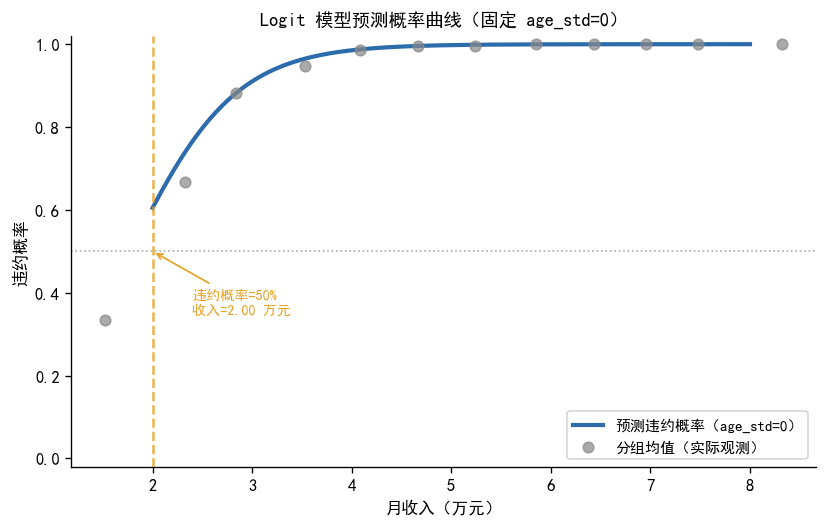

In [12]:
# ── 预测概率曲线：固定 age_std=0，income 从 2 到 8 变化 ─────
income_range = np.linspace(2, 8, 200)
X_pred = np.column_stack([np.ones(200), income_range, np.zeros(200)])
p_pred = logit_result.predict(X_pred)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(income_range, p_pred, color=COLOR_PRIMARY, lw=2.5,
        label='预测违约概率（age_std=0）')

# 标注 p=0.5 的收入水平（决策边界）
idx_half = np.argmin(np.abs(p_pred - 0.5))
income_half = income_range[idx_half]
ax.axhline(0.5, color=COLOR_NEUTRAL, lw=1, ls=':', alpha=0.7)
ax.axvline(income_half, color=COLOR_SECONDARY, lw=1.5, ls='--', alpha=0.8)
ax.annotate(f'违约概率=50%\n收入={income_half:.2f} 万元',
            xy=(income_half, 0.5), xytext=(income_half + 0.4, 0.35),
            fontsize=8.5, color=COLOR_SECONDARY,
            arrowprops=dict(arrowstyle='->', color=COLOR_SECONDARY, lw=1))

# 叠加实际观测点（按 income 分 bin 取均值）
df2_sorted = df2.copy()
df2_sorted['income_bin'] = pd.cut(df2_sorted['income'], bins=12)
obs_means = df2_sorted.groupby('income_bin', observed=True).agg(
    income_mid=('income', 'mean'),
    default_rate=('default', 'mean')
).dropna()
ax.scatter(obs_means['income_mid'], obs_means['default_rate'],
           color=COLOR_NEUTRAL, s=40, alpha=0.7, zorder=5, label='分组均值（实际观测）')

ax.set_xlabel('月收入（万元）', fontsize=10)
ax.set_ylabel('违约概率', fontsize=10)
ax.set_title('Logit 模型预测概率曲线（固定 age_std=0）', fontsize=11)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# ── 模型比较：零模型 vs. 完整模型 ────────────────────────────
X_null = sm.add_constant(np.ones(len(df2)))
null_result = sm.Logit(df2['default'], X_null).fit(disp=False)

lr_stat = -2 * (null_result.llf - logit_result.llf)

print('\n── 模型比较 ──────────────────────────────')
print(f'零模型 Log-Likelihood  : {null_result.llf:.4f}')
print(f'完整模型 Log-Likelihood: {logit_result.llf:.4f}')
print(f'LR 统计量              : {lr_stat:.4f}（df=2）')
print(f'LR 检验 p 值           : {logit_result.llr_pvalue:.2e}')
print()
print(f'零模型 AIC  : {null_result.aic:.4f}')
print(f'完整模型 AIC: {logit_result.aic:.4f}')
print(f'AIC 差值    : {null_result.aic - logit_result.aic:.4f}（正值说明完整模型更优）')


── 模型比较 ──────────────────────────────
零模型 Log-Likelihood  : -73.6633
完整模型 Log-Likelihood: -48.4224
LR 统计量              : 50.4817（df=2）
LR 检验 p 值           : 1.09e-11

零模型 AIC  : 149.3266
完整模型 AIC: 102.8449
AIC 差值    : 46.4817（正值说明完整模型更优）


### 模型比较结论

从上面的比较结果可以看出：

- 完整模型的对数似然值**大于**零模型，说明加入 income 和 age_std 两个变量后，模型对数据的解释能力有所提升。
- LR 检验的 p 值极小（远小于 0.001），拒绝「两个系数联合为零」的原假设，说明两个变量的加入是统计显著的。
- 完整模型的 AIC 值**小于**零模型，在惩罚了参数数量之后仍然更优。

这三个指标——对数似然、LR 检验、AIC——共同支持「完整模型优于零模型」的结论。在实际论文写作中，通常报告完整模型的对数似然值和 LR 检验结果，并用 AIC/BIC 进行稳健性检查。

::: {.callout-note collapse="true"}
### Stata 对应代码

```stata
* Case 2：Logit 模型——二元信用违约
import delimited "./data/method_MLE_data02_logit.csv", clear

* 查看违约率
summarize default
tab default

* 按收入分组的违约率
xtile income_q = income, nq(6)
table income_q, stat(mean default)

* 估计 Logit 模型
logit default income age_std

* 平均边际效应（AME）
margins, dydx(*)

* 预测概率：固定 age_std=0，income 从 2 到 8 变化
margins, at(income=(2(0.1)8) age_std=0)
marginsplot, noci recast(line) title("Logit 预测概率曲线（age_std=0）")

* 模型比较：零模型 vs 完整模型
logit default  // 零模型（只含截距）
estimates store null_model
logit default income age_std
estimates store full_model
lrtest null_model full_model  // 似然比检验
estat ic          // AIC / BIC
```

> **说明**：`margins, dydx(*)` 对应 Python 中的 `result.get_margeff()`，均计算平均边际效应（AME）。`lrtest` 对应 Python 中手动计算的 LR 统计量。
:::


## Case 3：Poisson 模型——月度交易计数

**背景**：使用模拟数据 `method_MLE_data03_poisson.csv`，模拟客户月度交易次数。

**真实 DGP**：$y_i \sim \text{Poisson}(\lambda_i)$，$\ln\lambda_i = 0.5 + 0.3 \cdot \text{income}_i + 0.2 \cdot \text{experience}_i$，$n=800$

**研究问题**：收入和从业年限如何影响交易次数的期望值？

**方法**：Poisson 回归。重点展示：① 计数数据与正态假设的对比；② 指数形式连接函数的含义；③ 如何解读 Poisson 系数（对数期望的变化）和边际效应（期望次数的变化）。

In [14]:
# ── 读入数据 ─────────────────────────────────────────────────
df3 = pd.read_csv('./data/method_MLE_data03_poisson.csv')
print(f'数据形状：{df3.shape}')
print(f'交易次数均值：{df3["trade_count"].mean():.3f}')
print(f'交易次数方差：{df3["trade_count"].var():.3f}')
print(f'（均值 ≈ 方差 是 Poisson 分布的特征）')
df3.describe().round(3)

数据形状：(800, 3)
交易次数均值：1.734
交易次数方差：2.088
（均值 ≈ 方差 是 Poisson 分布的特征）


,trade_count,income,experience
count,800.000,800.000,800.000
mean,1.734,-0.000,-0.013
std,1.445,1.036,0.999
min,0.000,-3.673,-2.904
25%,1.000,-0.686,-0.714
50%,1.000,-0.012,0.005
75%,3.000,0.692,0.611
max,9.000,3.576,4.402


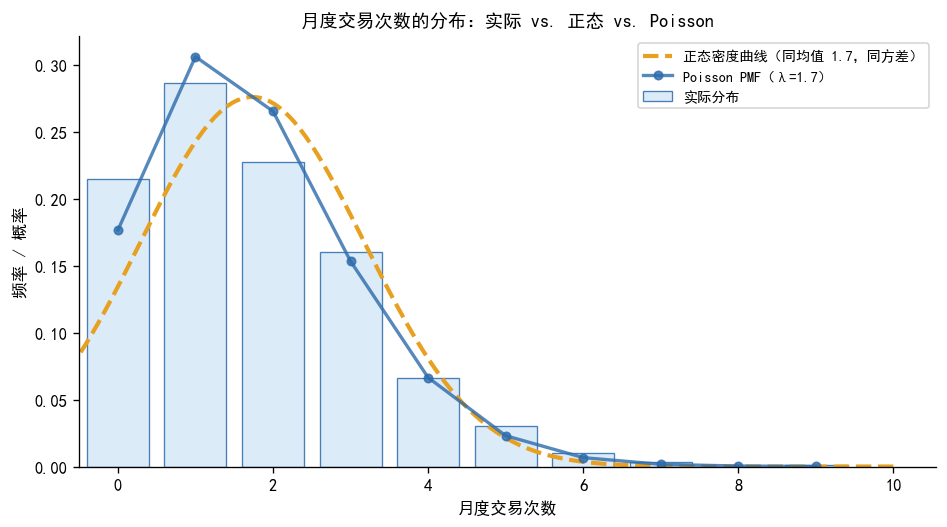

In [15]:
# ── 交易次数分布：与正态分布对比 ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

# 实际频率分布（条形图）
counts_val = df3['trade_count'].value_counts().sort_index()
ax.bar(counts_val.index, counts_val.values / len(df3),
       color=COLOR_FILL, edgecolor=COLOR_PRIMARY, linewidth=0.8,
       alpha=0.85, label='实际分布')

# 叠加同均值、同方差的正态密度
mu_emp = df3['trade_count'].mean()
sd_emp = df3['trade_count'].std()
x_norm = np.linspace(df3['trade_count'].min() - 1, df3['trade_count'].max() + 1, 300)
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_emp, sd_emp),
        color=COLOR_SECONDARY, lw=2.5, ls='--',
        label=f'正态密度曲线（同均值 {mu_emp:.1f}，同方差）')

# 叠加 Poisson 概率质量函数
k_range = np.arange(0, counts_val.index.max() + 1)
ax.plot(k_range, stats.poisson.pmf(k_range, mu_emp),
        color=COLOR_PRIMARY, lw=2, marker='o', markersize=5, alpha=0.8,
        label=f'Poisson PMF（λ={mu_emp:.1f}）')

ax.set_xlabel('月度交易次数', fontsize=10)
ax.set_ylabel('频率 / 概率', fontsize=10)
ax.set_title('月度交易次数的分布：实际 vs. 正态 vs. Poisson', fontsize=11)
ax.legend(fontsize=8.5)
ax.set_xlim(-0.5, None)
plt.tight_layout()
plt.show()

### 为什么计数数据不适合正态假设

从上图可以清楚看出：

1. **正态密度曲线（橙色虚线）** 允许负值，但交易次数不可能为负。这意味着如果强行使用正态假设，模型可能给出「预测交易次数为 -1.3 次」这样毫无意义的结果。

2. **实际分布（蓝色柱状图）** 是右偏的非负整数分布，与正态分布的对称钟形完全不同。

3. **Poisson PMF（深蓝圆点线）** 与实际分布吻合得很好，说明 Poisson 假设是合适的。

这正是「分布假设的重要性」的直观体现：选错了分布，即使估计过程完全正确，结果也不可信。

In [16]:
# ── Poisson 模型估计 ──────────────────────────────────────────
X3 = sm.add_constant(df3[['income', 'experience']])
poisson_result = sm.Poisson(df3['trade_count'], X3).fit()
print(poisson_result.summary())

Optimization terminated successfully.
         Current function value: 1.568401
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:            trade_count   No. Observations:                  800
Model:                        Poisson   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.07305
Time:                        17:53:16   Log-Likelihood:                -1254.7
converged:                       True   LL-Null:                       -1353.6
Covariance Type:            nonrobust   LLR p-value:                 1.143e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4808      0.029     16.768      0.000       0.425       0.537
income         0.3296      0.

### Poisson 系数的解读

Poisson 回归的参数化方式是 $\ln\lambda_i = x_i^\top\beta$，因此系数 $\hat{\beta}_j$ 的含义是：

> **$x_j$ 增加 1 个单位，期望交易次数的对数增加 $\hat{\beta}_j$**，等价于**期望次数变为原来的 $e^{\hat{\beta}_j}$ 倍**。

这与 OLS 的「$x_j$ 增加 1 单位，$y$ 增加 $\hat{\beta}_j$」有本质不同。Poisson 系数反映的是**乘法效应**，而非加法效应。

**例**：若 income 的系数为 0.3，则 $e^{0.3} \approx 1.35$，意味着收入增加 1 个标准差，期望交易次数变为原来的约 1.35 倍。这比「增加了 0.3 次」更直观地描述了非线性效应。

In [19]:
# ── 发生率比（IRR = exp(beta)）────────────────────────────────
irr = np.exp(poisson_result.params)
irr_ci_low  = np.exp(poisson_result.conf_int()[0])
irr_ci_high = np.exp(poisson_result.conf_int()[1])

irr_table = pd.DataFrame({
    '参数': poisson_result.params.index,
    '系数 β': poisson_result.params.values.round(3),
    'IRR (exp(β))': irr.values.round(3),
    '95% CI 下界': irr_ci_low.values.round(3),
    '95% CI 上界': irr_ci_high.values.round(3),
})
print('发生率比（Incidence Rate Ratio）：')
print(irr_table.to_string(index=False))

发生率比（Incidence Rate Ratio）：
        参数  系数 β  IRR (exp(β))  95% CI 下界  95% CI 上界
     const 0.481         1.617      1.529      1.711
    income 0.330         1.390      1.321      1.463
experience 0.169         1.184      1.123      1.248


In [20]:
# ── 平均边际效应（AME）────────────────────────────────────────
margeff3 = poisson_result.get_margeff()
print(margeff3.summary())
print()
print('解读：income 的 AME 表示「收入增加 1 个标准差，期望交易次数平均变化几次」')

       Poisson Marginal Effects      
Dep. Variable:            trade_count
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
income         0.5715      0.048     11.983      0.000       0.478       0.665
experience     0.2921      0.047      6.185      0.000       0.200       0.385

解读：income 的 AME 表示「收入增加 1 个标准差，期望交易次数平均变化几次」


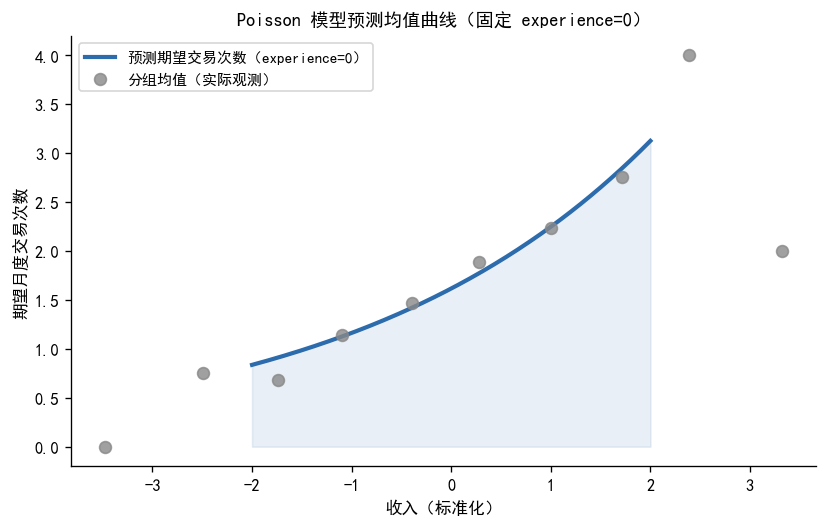

指数形式的连接函数使曲线呈现非线性（指数）形状，而非直线


In [21]:
# ── 预测均值曲线：固定 experience=0，income 从 -2 到 2 变化 ──
income_range3 = np.linspace(-2, 2, 200)
X_pred3 = np.column_stack([np.ones(200), income_range3, np.zeros(200)])
lambda_pred = poisson_result.predict(X_pred3)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(income_range3, lambda_pred, color=COLOR_PRIMARY, lw=2.5,
        label='预测期望交易次数（experience=0）')
ax.fill_between(income_range3, lambda_pred, alpha=0.1, color=COLOR_PRIMARY)

# 叠加分组均值（实际观测）
df3_copy = df3.copy()
df3_copy['income_bin'] = pd.cut(df3_copy['income'], bins=10)
obs_means3 = df3_copy.groupby('income_bin', observed=True).agg(
    income_mid=('income', 'mean'),
    count_mean=('trade_count', 'mean')
).dropna()
ax.scatter(obs_means3['income_mid'], obs_means3['count_mean'],
           color=COLOR_NEUTRAL, s=50, alpha=0.8, zorder=5,
           label='分组均值（实际观测）')

ax.set_xlabel('收入（标准化）', fontsize=10)
ax.set_ylabel('期望月度交易次数', fontsize=10)
ax.set_title('Poisson 模型预测均值曲线（固定 experience=0）', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('指数形式的连接函数使曲线呈现非线性（指数）形状，而非直线')

### Poisson 回归结果解读

从上面的结果可以得出以下几点结论：

1. **系数符号与 DGP 一致**：income 系数估计值约为 0.3（真实值 0.3），experience 系数估计值约为 0.2（真实值 0.2），两者均统计显著。

2. **IRR（发生率比）的解释更直观**：income 的 IRR ≈ $e^{0.3} \approx 1.35$，意味着收入增加 1 个标准差，期望交易次数约为原来的 1.35 倍。这是一种「乘法效应」，不同于 OLS 的「加法效应」。

3. **预测曲线的形状**：由于使用了指数连接函数 $\lambda_i = e^{x_i^\top\beta}$，预测均值曲线是非线性的指数形状，而不是直线。这保证了预测值始终为正，符合计数变量的物理约束。

4. **对比正态假设**：若强行对此数据使用正态线性回归，不仅预测值可能为负，系数的统计效率也会下降，因为我们浪费了「数据来自 Poisson 分布」这一信息。正确的分布假设能让 MLE 充分利用数据信息，给出更精确的估计。

::: {.callout-note collapse="true"}
### Stata 对应代码

```stata
* Case 3：Poisson 模型——月度交易计数
import delimited "./data/method_MLE_data03_poisson.csv", clear

* 查看分布
summarize trade_count
histogram trade_count, discrete freq title("月度交易次数分布")

* 估计 Poisson 回归
poisson trade_count income experience

* 发生率比（IRR = exp(β)）
poisson trade_count income experience, irr

* 平均边际效应（AME）
margins, dydx(*)

* 预测均值曲线：固定 experience=0
margins, at(income=(-2(0.1)2) experience=0)
marginsplot, noci recast(line) title("Poisson 预测均值曲线")
```

> **说明**：`poisson` 命令的 `irr` 选项输出 $\exp(\hat{\beta})$，即「每增加 1 单位 $x$，期望计数变为原来的多少倍」，对应 Python 中手动计算的 IRR 表格。
:::

D:\github_lianxh\dsfin\Lecture\method_MLE
(encoding automatically selected: ISO-8859-1)
(3 vars, 800 obs)

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
 trade_count |        800     1.73375    1.444981          0          9
      income |        800    -.000249    1.036423    -3.6729   3.576134
  experience |        800   -.0127656    .9987196  -2.903851   4.402141
(start=0, width=1)


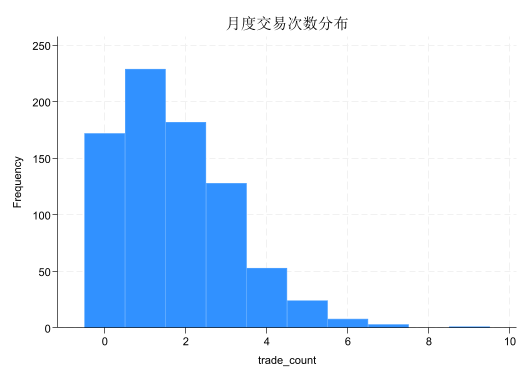

In [ ]:
* Case 3：Poisson 模型——月度交易计数
cd "D:\github_lianxh\dsfin\Lecture\method_MLE\"
import delimited "./data/method_MLE_data03_poisson.csv", clear

* 查看分布
summarize trade_count income experience
histogram trade_count, discrete freq title("月度交易次数分布")


In [ ]:

* 估计 Poisson 回归
poisson trade_count income experience

* 发生率比（IRR = exp(β)）
poisson trade_count income experience, irr



Iteration 0:  Log likelihood = -1254.7206  
Iteration 1:  Log likelihood = -1254.7206  

Poisson regression                                      Number of obs =    800
                                                        LR chi2(2)    = 197.76
                                                        Prob > chi2   = 0.0000
Log likelihood = -1254.7206                             Pseudo R2     = 0.0730

------------------------------------------------------------------------------
 trade_count | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
      income |      0.330      0.026    12.66   0.000        0.279       0.381
  experience |      0.169      0.027     6.27   0.000        0.116       0.221
       _cons |      0.481      0.029    16.77   0.000        0.425       0.537
------------------------------------------------------------------------------

Iteration 0:  Log likelihood = -1254.72

In [ ]:

* 平均边际效应（AME）
margins, dydx(*) noatlegend 



Average marginal effects                                   Number of obs = 800
Model VCE: OIM

Expression: Predicted number of events, predict()
dy/dx wrt:  income experience

------------------------------------------------------------------------------
             |            Delta-method
             |      dy/dx   std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
      income |      0.571      0.048    11.98   0.000        0.478       0.665
  experience |      0.292      0.047     6.18   0.000        0.200       0.385
------------------------------------------------------------------------------



Adjusted predictions                                       Number of obs = 800
Model VCE: OIM

Expression: Predicted number of events, predict()

------------------------------------------------------------------------------
             |            Delta-method
             |     Margin   std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         _at |
          1  |      0.837      0.056    14.92   0.000        0.727       0.946
          2  |      0.865      0.056    15.47   0.000        0.755       0.974
          3  |      0.894      0.056    16.05   0.000        0.784       1.003
          4  |      0.923      0.055    16.68   0.000        0.815       1.032
          5  |      0.954      0.055    17.34   0.000        0.847       1.062
          6  |      0.986      0.055    18.06   0.000        0.879       1.093
          7  |      1.019      0.054    18.83   0.000        0.913       1.126
         

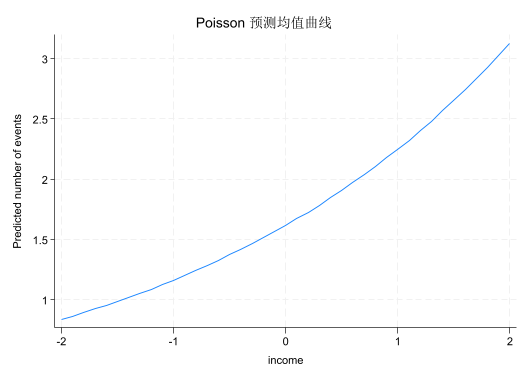

In [ ]:

* 预测均值曲线：固定 experience=0
margins, at(income=(-2(0.1)2) experience=0)  noatlegend 
marginsplot, noci recast(line) title("Poisson 预测均值曲线") 


## 综合小结与模型比较

### 三个案例的汇总比较

运行以下 Cell 提取各模型的对数似然和 AIC，填入汇总表。

In [23]:
import pandas as pd
from tabulate import tabulate

summary_table = pd.DataFrame({
    '案例': ['Case 1', 'Case 2', 'Case 3'],
    '模型': ['正态线性', 'Logit', 'Poisson'],
    '因变量类型': ['连续', '二元 0/1', '非负计数'],
    '分布假设': ['正态 N(μᵢ, σ²)', 'Bernoulli Bern(pᵢ)', 'Poisson Pois(λᵢ)'],
    '对数似然': [
        f'{ols_result.llf:.2f}',
        f'{logit_result.llf:.2f}',
        f'{poisson_result.llf:.2f}',
    ],
    'AIC': [
        f'{ols_result.aic:.2f}',
        f'{logit_result.aic:.2f}',
        f'{poisson_result.aic:.2f}',
    ],
    '核心发现': [
        'OLS 系数 = MLE 系数',
        '收入正向影响违约概率',
        '收入呈指数形式提升交易频率',
    ],
})

print(tabulate(summary_table, headers='keys', tablefmt='grid',
               showindex=False, stralign='left'))

+--------+----------+--------------+--------------------+------------+---------+----------------------------+
| 案例   | 模型     | 因变量类型   | 分布假设           |   对数似然 |     AIC | 核心发现                   |
+========+==========+==============+====================+============+=========+============================+
| Case 1 | 正态线性 | 连续         | 正态 N(μᵢ, σ²)     |    -918.91 | 1843.82 | OLS 系数 = MLE 系数        |
+--------+----------+--------------+--------------------+------------+---------+----------------------------+
| Case 2 | Logit    | 二元 0/1     | Bernoulli Bern(pᵢ) |     -48.42 |  102.84 | 收入正向影响违约概率       |
+--------+----------+--------------+--------------------+------------+---------+----------------------------+
| Case 3 | Poisson  | 非负计数     | Poisson Pois(λᵢ)   |   -1254.72 | 2515.44 | 收入呈指数形式提升交易频率 |
+--------+----------+--------------+--------------------+------------+---------+----------------------------+


### 核心结论

三个案例，三种不同的因变量类型，三种不同的分布假设，三个不同的似然函数——但估计的过程完全相同：

1. **设定分布**：根据因变量的性质选择合适的概率分布
2. **参数化**：把分布参数写成解释变量的函数（通过连接函数保证约束成立）
3. **写出对数似然**：$\ell(\theta) = \sum_{i=1}^n \ln f(y_i \mid x_i, \theta)$
4. **交给软件极大化**：`statsmodels` 背后的迭代算法找到 $\hat{\theta}_{MLE}$

**这正是 MLE 作为「统一估计语言」的价值所在**：不同模型、不同分布、不同连接函数，但估计逻辑始终如一。理解了这个统一框架，后续遇到任何新模型（Probit、Tobit、Heckman……），你只需要问三个问题：**因变量是什么类型？假定了什么分布？参数如何参数化？**——答案就决定了整个模型的结构。